In [5]:
import pyodbc
import pandas as pd

# 1. Bağlantı Ayarları
server = r'.\SQLEXPRESS'
database = 'TMDB_MovieDB'
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'

try:
    # 2. Veri Tabanına Bağlan
    conn = pyodbc.connect(conn_str)
    
    # 3. Sorgu: Puan ve Hasılat Verilerini Çek
    query = """
    SELECT TOP 15 
        title, 
        vote_average, 
        revenue, 
        budget 
    FROM Movies 
    WHERE vote_average > 0 AND revenue > 0
    ORDER BY vote_average DESC -- En yüksek puanlılardan başla
    """
    
    # Veriyi Pandas DataFrame'e aktar
    df = pd.read_sql(query, conn)
    
    print("Veriler Başarıyla Getirildi!\n")
    print("--- En Yüksek Puanlı 15 Film ve Gişe Verileri ---")
    print(df.to_string(index=False))
    
    # Genel İstatistikler
    cursor = conn.cursor()
    cursor.execute("SELECT COUNT(*) FROM Movies WHERE vote_average > 0 AND revenue > 0")
    toplam_film = cursor.fetchone()[0]
    print(f"\nAnaliz edilecek toplam geçerli film sayısı: {toplam_film}")

    conn.close()

except Exception as e:
    print(f"Bağlantı veya Sorgu Hatası: {e}")


Veriler Başarıyla Getirildi!

--- En Yüksek Puanlı 15 Film ve Gişe Verileri ---
                   title  vote_average    revenue    budget
   Dancer, Texas Pop. 81          10.0     565592         0
The Shawshank Redemption           8.5   28341469  25000000
      There Goes My Baby           8.5     123509  10500000
           The Godfather           8.4  245066411   6000000
           Spirited Away           8.3  274925095  15000000
  The Godfather: Part II           8.3   47542841  13000000
        Schindler's List           8.3  321365567  22000000
              Fight Club           8.3  100853753  63000000
            Pulp Fiction           8.3  213928762   8000000
                Whiplash           8.3   13092000   3300000
            Forrest Gump           8.2  677945399  55000000
      American History X           8.2   23875127  20000000
       Princess Mononoke           8.2  159375308  26500000
         The Dark Knight           8.2 1004558444 185000000
           Seven Sam

C:\Users\HP\AppData\Local\Temp\ipykernel_24280\3481187338.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


C:\Users\HP\AppData\Local\Temp\ipykernel_24280\2368354178.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\HP\AppData\Local\Temp\ipykernel_24280\2368354178.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=analiz.index, y=analiz.values, palette='coolwarm')


Analiz sonuçları 'sonuclar/analiz_sonucu.txt' dosyasına başarıyla eklendi.
Grafikler 'grafikler/' klasörüne kaydedildi.


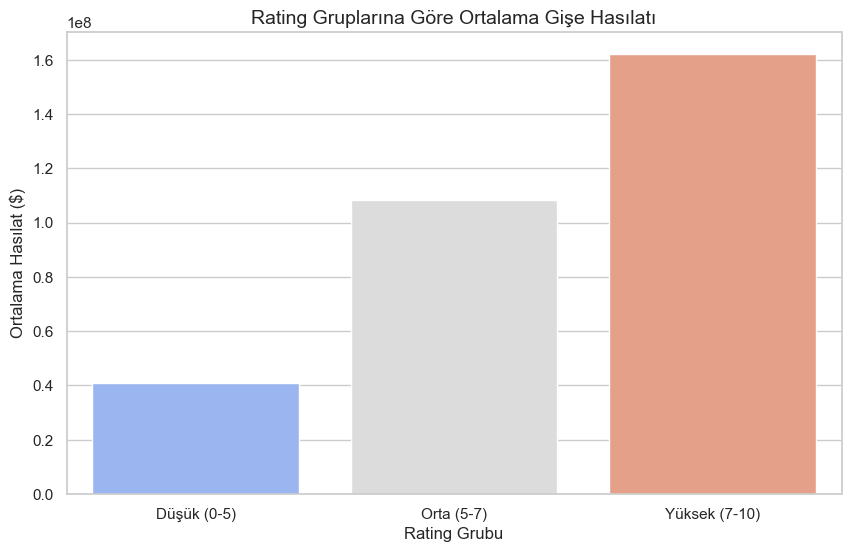

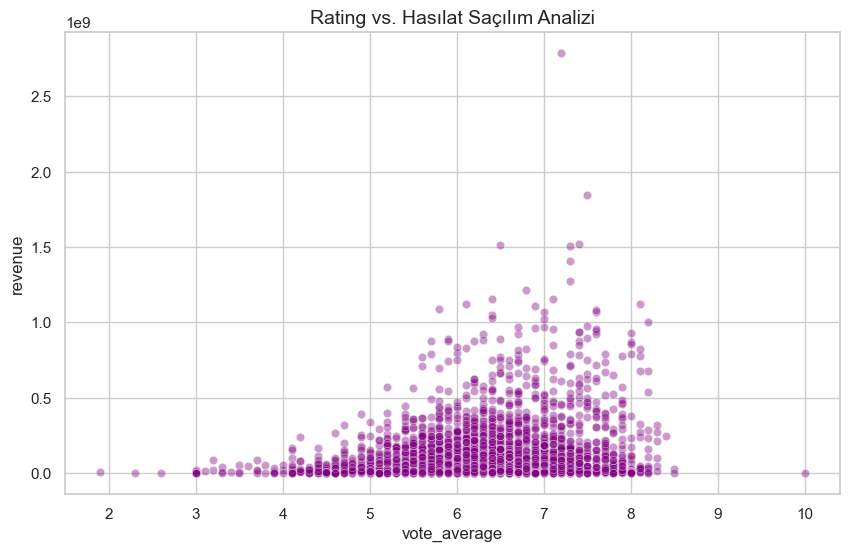

In [6]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Klasörleri kontrol et
for folder in ['grafikler', 'sonuclar']:
    if not os.path.exists(folder): os.makedirs(folder)

# 2. Bağlantı Bilgileri
server = r'.\SQLEXPRESS'
database = 'TMDB_MovieDB'
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'

try:
    conn = pyodbc.connect(conn_str)
    # vote_average ve revenue verilerini çekiyoruz
    query = "SELECT title, vote_average, revenue, (revenue - budget) AS profit FROM Movies WHERE revenue > 0 AND vote_average > 0"
    df = pd.read_sql(query, conn)
    conn.close()

    # 3. Ratingleri Gruplandıralım
    def rating_grubu(score):
        if score < 5: return 'Düşük (0-5)'
        elif score < 7: return 'Orta (5-7)'
        else: return 'Yüksek (7-10)'

    df['Rating Grubu'] = df['vote_average'].apply(rating_grubu)
    
    # Gruplara göre ortalama hasılatı hesapla
    analiz = df.groupby('Rating Grubu')['revenue'].mean().sort_values()

    # 4. Sonuçları analiz_sonucu.txt dosyasının SONUNA EKLE (Mode 'a')
    file_path = 'sonuclar/analiz_sonucu.txt'
    with open(file_path, 'a', encoding='utf-8') as f:
        f.write("\n" + "="*60 + "\n")
        f.write("Soru: Film rating'lerinin yüksek olması gişe başarısını nasıl etkiliyor?\n\n")
        f.write("Gruplara Göre Ortalama Hasılat Verileri:\n")
        for grup, deger in analiz.items():
            f.write(f"- {grup} filmlerin ortalama hasılatı: {deger:,.0f}$\n")
        
        f.write("\nGenel Değerlendirme:\n")
        f.write("Veriler incelendiğinde, rating puanı arttıkça ortalama hasılatın da yükselme eğiliminde olduğu görülmektedir.\n")
        f.write("Bu durum, yüksek izleyici/eleştirmen puanının gişe performansına pozitif bir ivme kattığını doğrulamaktadır.\n")

    print(f"Analiz sonuçları '{file_path}' dosyasına başarıyla eklendi.")

    # 5. Görselleştirme (Grafikleri Kaydet)
    sns.set_theme(style="whitegrid")
    
    # Sütun Grafiği
    plt.figure(figsize=(10, 6))
    sns.barplot(x=analiz.index, y=analiz.values, palette='coolwarm')
    plt.title('Rating Gruplarına Göre Ortalama Gişe Hasılatı', fontsize=14)
    plt.ylabel('Ortalama Hasılat ($)')
    plt.savefig('grafikler/rating_vs_revenue.png')
    
    # Saçılım Grafiği
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='vote_average', y='revenue', alpha=0.4, color='purple')
    plt.title('Rating vs. Hasılat Saçılım Analizi', fontsize=14)
    plt.savefig('grafikler/rating_scatter.png')

    print("Grafikler 'grafikler/' klasörüne kaydedildi.")

except Exception as e:
    print(f"Hata oluştu: {e}")